#Quantium Virtual Internship - Retail Strategy and Analytics - Task 1


In [54]:
# Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
from scipy import stats

In [55]:
# Load datasets
c_df = pd.read_csv('QVI_purchase_behaviour.csv')
t_df = pd.read_excel('/content/QVI_transaction_data.xlsx')

In [56]:
t_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [57]:
t_df.shape

(264836, 8)

In [58]:
t_df.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


In [59]:
t_df.duplicated().sum()

np.int64(1)

In [60]:
t_df.drop_duplicates(inplace=True)

###Exploratory Data Analysis - Transaction Data

In [61]:
print(t_df.dtypes)
print(t_df.head())

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object
    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  


In [62]:

# Convert DATE from Excel integer format to datetime
# Excel/CSV integer dates begin on 30 Dec 1899
t_df["DATE"] = pd.to_datetime(t_df["DATE"], unit="D", origin="1899-12-30")

In [63]:
# Examine PROD_NAME
print(t_df["PROD_NAME"].value_counts().head(10))

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
Kettle 135g Swt Pot Sea Salt                3257
Tostitos Splash Of  Lime 175g               3252
Infuzions Thai SweetChili PotatoMix 110g    3242
Smiths Crnkle Chip  Orgnl Big Bag 380g      3233
Thins Potato Chips  Hot & Spicy 175g        3229
Name: count, dtype: int64


As we are only interested in words that will tell us if the product is chips or not, let’s remove all words with
digits and special characters such as ‘&’ from our set of product words.

In [64]:
# Extract individual words from product names
all_words = " ".join(t_df["PROD_NAME"].unique()).split()
product_words = pd.Series(all_words)
print(all_words)

['Natural', 'Chip', 'Compny', 'SeaSalt175g', 'CCs', 'Nacho', 'Cheese', '175g', 'Smiths', 'Crinkle', 'Cut', 'Chips', 'Chicken', '170g', 'Smiths', 'Chip', 'Thinly', 'S/Cream&Onion', '175g', 'Kettle', 'Tortilla', 'ChpsHny&Jlpno', 'Chili', '150g', 'Old', 'El', 'Paso', 'Salsa', 'Dip', 'Tomato', 'Mild', '300g', 'Smiths', 'Crinkle', 'Chips', 'Salt', '&', 'Vinegar', '330g', 'Grain', 'Waves', 'Sweet', 'Chilli', '210g', 'Doritos', 'Corn', 'Chip', 'Mexican', 'Jalapeno', '150g', 'Grain', 'Waves', 'Sour', 'Cream&Chives', '210G', 'Kettle', 'Sensations', 'Siracha', 'Lime', '150g', 'Twisties', 'Cheese', '270g', 'WW', 'Crinkle', 'Cut', 'Chicken', '175g', 'Thins', 'Chips', 'Light&', 'Tangy', '175g', 'CCs', 'Original', '175g', 'Burger', 'Rings', '220g', 'NCC', 'Sour', 'Cream', '&', 'Garden', 'Chives', '175g', 'Doritos', 'Corn', 'Chip', 'Southern', 'Chicken', '150g', 'Cheezels', 'Cheese', 'Box', '125g', 'Smiths', 'Crinkle', 'Original', '330g', 'Infzns', 'Crn', 'Crnchers', 'Tangy', 'Gcamole', '110g', 'Kett

In [65]:
# Remove words containing digits
product_words = product_words[~product_words.str.contains(r"\d", regex=True)]

In [66]:
# Keep only words with alphabetic characters
product_words = product_words[product_words.str.contains(r"[a-zA-Z]", regex=True)]

In [67]:
#Most Common Product Words
print(product_words.value_counts().head(20))

Chips       21
Smiths      16
Cut         14
Crinkle     14
Kettle      13
Salt        12
Cheese      12
Original    10
Chip         9
Doritos      9
Salsa        9
Corn         8
Pringles     8
RRD          8
Chicken      7
WW           7
Sour         6
Sea          6
Vinegar      5
Thins        5
Name: count, dtype: int64


There are salsa products in the dataset but we are only interested in the chips category, so let’s remove
these.

In [68]:
# Remove salsa products
t_df = t_df[~t_df["PROD_NAME"].str.lower().str.contains("salsa")].copy()

In [69]:
#Transaction Data Summary ===")
print(t_df.describe())

                                DATE      STORE_NBR  LYLTY_CARD_NBR  \
count                         246741  246741.000000    2.467410e+05   
mean   2018-12-30 01:19:32.745510656     135.051212    1.355311e+05   
min              2018-07-01 00:00:00       1.000000    1.000000e+03   
25%              2018-09-30 00:00:00      70.000000    7.001500e+04   
50%              2018-12-30 00:00:00     130.000000    1.303670e+05   
75%              2019-03-31 00:00:00     203.000000    2.030840e+05   
max              2019-06-30 00:00:00     272.000000    2.373711e+06   
std                              NaN      76.787231    8.071542e+04   

             TXN_ID       PROD_NBR       PROD_QTY      TOT_SALES  
count  2.467410e+05  246741.000000  246741.000000  246741.000000  
mean   1.351312e+05      56.351835       1.908061       7.321328  
min    1.000000e+00       1.000000       1.000000       1.700000  
25%    6.756900e+04      26.000000       2.000000       5.800000  
50%    1.351840e+05      

There are no nulls in the columns but product quantity appears to have an outlier which we should investigate
further. Let’s investigate further the case where 200 packets of chips are bought in one transaction.

In [70]:
# Investigate outlier: PROD_QTY == 200
print(t_df[t_df["PROD_QTY"] == 200])

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


There are two transactions where 200 packets of chips are bought in one transaction and both of these
transactions where by the same customer.

In [71]:
# Check all transactions by the outlier customer
print(t_df[t_df["LYLTY_CARD_NBR"] == 226000])

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


It looks like this customer has only had the two transactions over the year and is not an ordinary retail
customer. The customer might be buying chips for commercial purposes instead. We’ll remove this loyalty
card number from further analysis.

In [72]:
# Remove the outlier customer
t_df = t_df[t_df["LYLTY_CARD_NBR"] != 226000].copy()

In [73]:
#Summary after removing outlier
print(t_df.describe())

                                DATE      STORE_NBR  LYLTY_CARD_NBR  \
count                         246739  246739.000000    2.467390e+05   
mean   2018-12-30 01:19:29.982856448     135.050474    1.355304e+05   
min              2018-07-01 00:00:00       1.000000    1.000000e+03   
25%              2018-09-30 00:00:00      70.000000    7.001500e+04   
50%              2018-12-30 00:00:00     130.000000    1.303670e+05   
75%              2019-03-31 00:00:00     203.000000    2.030835e+05   
max              2019-06-30 00:00:00     272.000000    2.373711e+06   
std                              NaN      76.787105    8.071534e+04   

             TXN_ID       PROD_NBR       PROD_QTY      TOT_SALES  
count  2.467390e+05  246739.000000  246739.000000  246739.000000  
mean   1.351305e+05      56.352259       1.906456       7.316118  
min    1.000000e+00       1.000000       1.000000       1.700000  
25%    6.756850e+04      26.000000       2.000000       5.800000  
50%    1.351820e+05      

That’s better. Now, let’s look at the number of transaction lines over time to see if there are any obvious data
issues such as missing data.

In [74]:
# Transactions over time
transactions_by_day = (t_df.groupby("DATE").size().reset_index(name="N"))

In [75]:
# Create full date range Jul 2018 - Jun 2019
all_dates = pd.DataFrame(
    {"DATE": pd.date_range("2018-07-01", "2019-06-30", freq="D")}
)
transactions_by_day = all_dates.merge(transactions_by_day, on="DATE", how="left")

In [76]:
print(f"\nNumber of dates with transactions: {transactions_by_day['N'].notna().sum()}")


Number of dates with transactions: 364


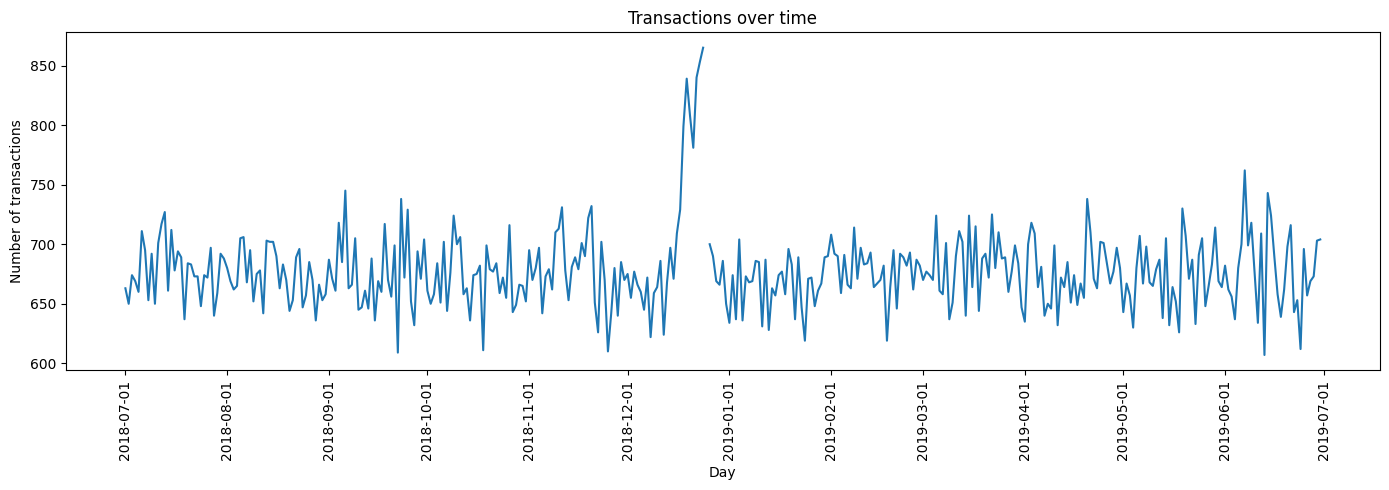

In [77]:
# Plot transactions over time
plt.figure(figsize=(14, 5))
plt.plot(transactions_by_day["DATE"], transactions_by_day["N"])
plt.title("Transactions over time")
plt.xlabel("Day")
plt.ylabel("Number of transactions")
plt.xticks(
    pd.date_range("2018-07-01", "2019-07-01", freq="MS"),
    rotation=90,
)
plt.tight_layout()
plt.savefig("transactions_over_time.png", dpi=150)
plt.show()

We can see that there is an increase in purchases in December and a break in late December. Let’s zoom in
on this.

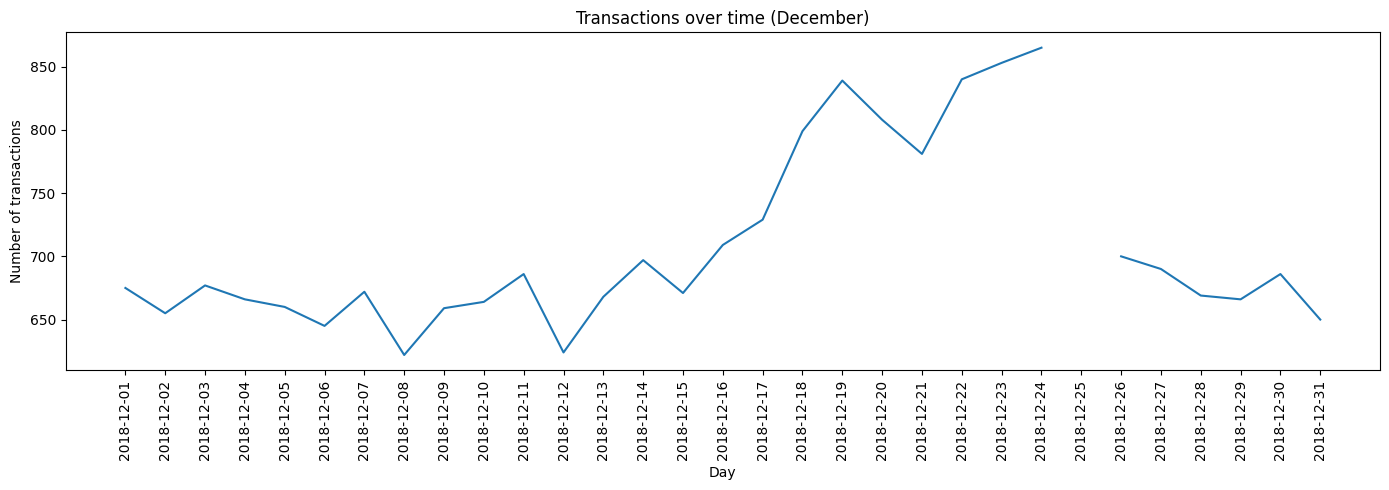

In [78]:
# Zoom into December
dec_data = transactions_by_day[transactions_by_day["DATE"].dt.month == 12]

plt.figure(figsize=(14, 5))
plt.plot(dec_data["DATE"], dec_data["N"])
plt.title("Transactions over time (December)")
plt.xlabel("Day")
plt.ylabel("Number of transactions")
plt.xticks(dec_data["DATE"], rotation=90)
plt.tight_layout()
plt.savefig("transactions_december.png", dpi=150)
plt.show()

We can see that the increase in sales occurs in the lead-up to Christmas and that there are zero sales on
Christmas day itself. This is due to shops being closed on Christmas day.

Now that weare satisfied that the data no longer has outliers,we can move on to creating other features
such as brand of chips or pack size from PROD_NAME. We will start  with pack size.

In [79]:
# Feature Engineering: Pack Size
t_df["PACK_SIZE"] = (
    t_df["PROD_NAME"]
    .str.extract(r"(\d+)g?", expand=False)
    .astype(float)
)

print("\nPack Size Counts")
print(t_df["PACK_SIZE"].value_counts().sort_index())


Pack Size Counts
PACK_SIZE
70.0      1507
90.0      3008
110.0    22387
125.0     1454
134.0    25102
135.0     3257
150.0    40203
160.0     2970
165.0    15297
170.0    19983
175.0    66389
180.0     1468
190.0     2995
200.0     4473
210.0     6272
220.0     1564
250.0     3169
270.0     6285
330.0    12540
380.0     6416
Name: count, dtype: int64


The largest size is 380g and the smallest size is 70g -seems sensible!

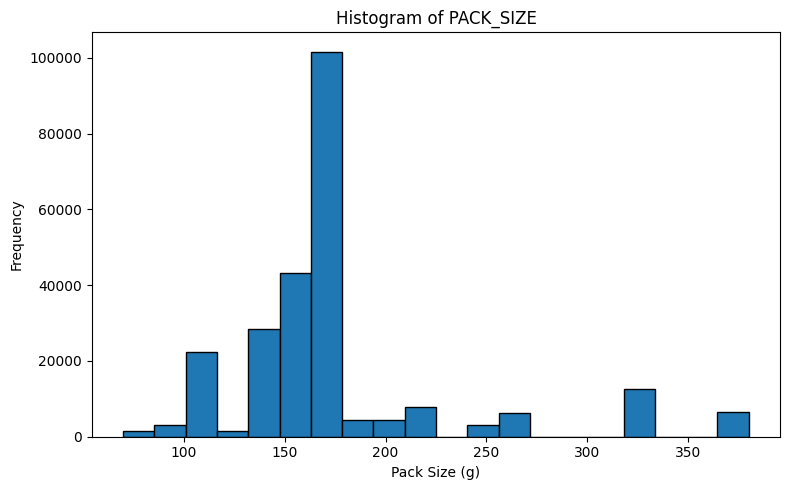

In [80]:
# Histogram of pack sizes
plt.figure(figsize=(8, 5))
plt.hist(t_df["PACK_SIZE"].dropna(), bins=20, edgecolor="black")
plt.title("Histogram of PACK_SIZE")
plt.xlabel("Pack Size (g)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("pack_size_histogram.png", dpi=150)
plt.show()

In [81]:
# Feature Engineering: Brand
t_df["BRAND"] = (
    t_df["PROD_NAME"]
    .str.split().str[0]
    .str.upper()
)

print("\n Brand Counts (before cleaning)")
print(t_df["BRAND"].value_counts())


 Brand Counts (before cleaning)
BRAND
KETTLE        41288
SMITHS        27389
PRINGLES      25102
DORITOS       22041
THINS         14075
RRD           11894
INFUZIONS     11057
WW            10320
COBS           9693
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
GRAIN          6272
NATURAL        6050
CHEEZELS       4603
CCS            4551
RED            4427
DORITO         3183
INFZNS         3144
SMITH          2963
CHEETOS        2927
SNBTS          1576
BURGER         1564
WOOLWORTHS     1516
GRNWVES        1468
SUNBITES       1432
NCC            1419
FRENCH         1418
Name: count, dtype: int64


Some of the brand names look like they are of the same brands- such as RED and RRD, which are both Red
Rock Deli chips. Let’s combine these together.


In [82]:
# Clean up brand names
brand_map = {
    "RED":    "RRD",
    "SNBTS":  "SUNBITES",
    "INFZNS": "INFUZIONS",
    "WW":     "WOOLWORTHS",
    "SMITH":  "SMITHS",
    "NCC":    "NATURAL",
    "DORITO": "DORITOS",
    "GRAIN":  "GRNWVES",
}
t_df["BRAND"] = t_df["BRAND"].replace(brand_map)

print("\n Brand Counts (after cleaning)")
print(t_df["BRAND"].value_counts().sort_index())


 Brand Counts (after cleaning)
BRAND
BURGER         1564
CCS            4551
CHEETOS        2927
CHEEZELS       4603
COBS           9693
DORITOS       25224
FRENCH         1418
GRNWVES        7740
INFUZIONS     14201
KETTLE        41288
NATURAL        7469
PRINGLES      25102
RRD           16321
SMITHS        30352
SUNBITES       3008
THINS         14075
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
WOOLWORTHS    11836
Name: count, dtype: int64


##Examine Customer Data

In [83]:
print(c_df.dtypes)
print(c_df.describe(include="all"))

LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object
        LYLTY_CARD_NBR LIFESTAGE PREMIUM_CUSTOMER
count     7.263700e+04     72637            72637
unique             NaN         7                3
top                NaN  RETIREES       Mainstream
freq               NaN     14805            29245
mean      1.361859e+05       NaN              NaN
std       8.989293e+04       NaN              NaN
min       1.000000e+03       NaN              NaN
25%       6.620200e+04       NaN              NaN
50%       1.340400e+05       NaN              NaN
75%       2.033750e+05       NaN              NaN
max       2.373711e+06       NaN              NaN


In [84]:
#Lifestage Counts
print(c_df["LIFESTAGE"].value_counts())

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64


In [85]:
#Premium Customer Counts
print(c_df["PREMIUM_CUSTOMER"].value_counts())

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [86]:
# Merge transaction and customer data
df = t_df.merge(c_df, on="LYLTY_CARD_NBR", how="left")

In [87]:
print(f"\nRows after merge: {len(df)} (should match transaction rows: {len(t_df)})")
print(f"Null LIFESTAGE: {df['LIFESTAGE'].isna().sum()}")


Rows after merge: 246739 (should match transaction rows: 246739)
Null LIFESTAGE: 0


In [88]:
print(f"Null PREMIUM_CUSTOMER: {df['PREMIUM_CUSTOMER'].isna().sum()}")

Null PREMIUM_CUSTOMER: 0


###Data Analysis on Customer Segments

Now that the data is ready for analysis, we can define some metrics of interest to the client:

• Who spends the most on chips(totalsales),describing customers by life stage
and how premium their general purchasing behaviour is

• How many customers are in each segment

• How many chips are bought per customer by segment

• What’s the average chip price by customer segment
We could also ask our data team for more information. Examples are:
12

• The customer’s total spend over the period and total spend for each transaction to under stand what
proportion of their grocery spendis on chips

• Proportion of customers in each customer segment overall to compare against the mix of customers
who purchase chip

In [89]:
#Total Sales by Lifestage and Premium Customer
sales = (
    df.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"]
    .sum()
    .reset_index(name="SALES")
)

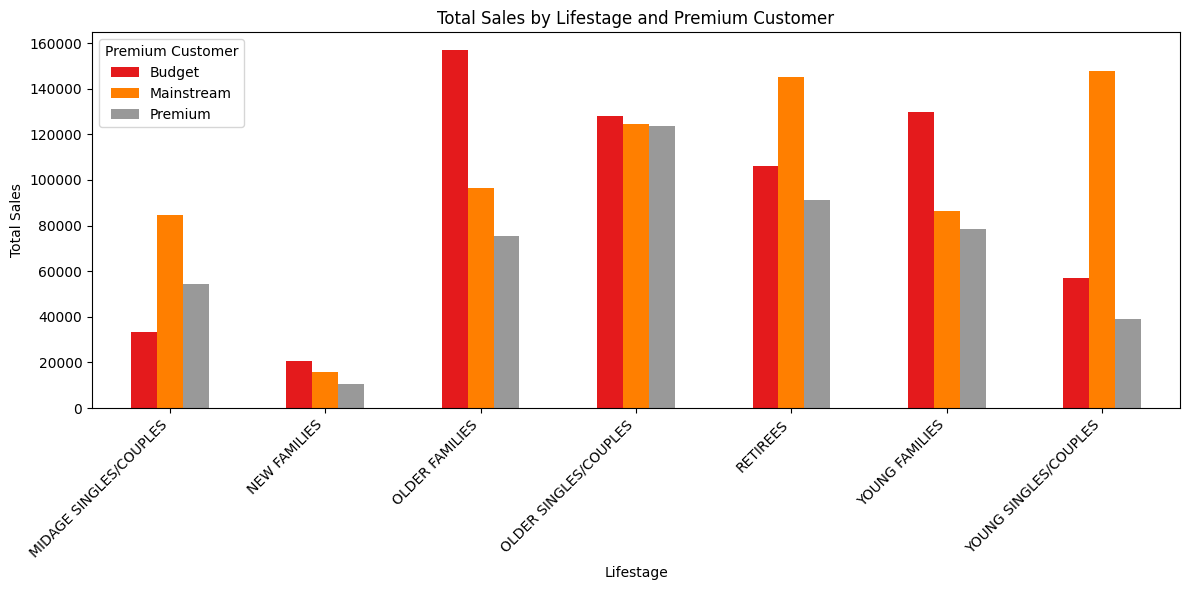

In [90]:
sales_pivot = sales.pivot(index="LIFESTAGE", columns="PREMIUM_CUSTOMER", values="SALES").fillna(0)

sales_pivot.plot(kind="bar", figsize=(12, 6), colormap="Set1")
plt.title("Total Sales by Lifestage and Premium Customer")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Premium Customer")
plt.tight_layout()
plt.savefig("total_sales_by_segment.png", dpi=150)
plt.show()


Sales are coming mainly from Budget-older families,Main stream-young singles/couples, and Main stream-retire.

In [91]:
# Number of Customers by Segment
customers = (
    df.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"]
    .nunique()
    .reset_index(name="CUSTOMERS")
)

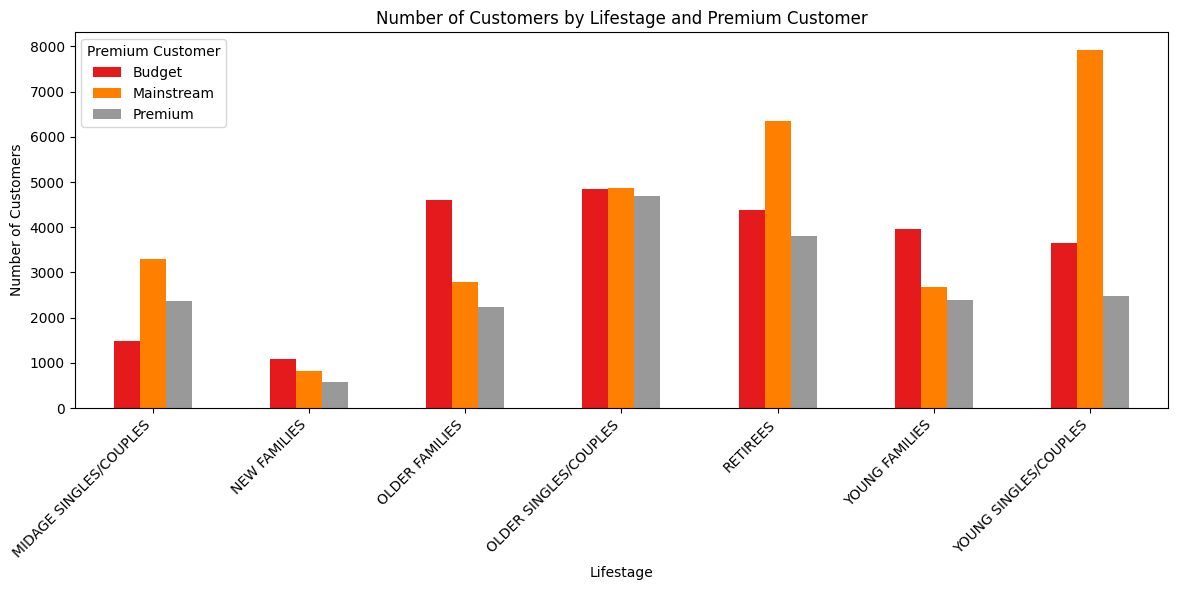

In [92]:
customers_pivot = customers.pivot(
    index="LIFESTAGE", columns="PREMIUM_CUSTOMER", values="CUSTOMERS"
).fillna(0)

customers_pivot.plot(kind="bar", figsize=(12, 6), colormap="Set1")
plt.title("Number of Customers by Lifestage and Premium Customer")
plt.xlabel("Lifestage")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Premium Customer")
plt.tight_layout()
plt.savefig("customers_by_segment.png", dpi=150)
plt.show()

There are more Mainstream- young singles/ couples and Mainstream- retirees who buy chips. This contributes to there being more sales to these customer segments but this is not a major driver for the Budget-Older families segment.

In [93]:
# Average Units per Customer
avg_units = (
    df.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .apply(lambda x: x["PROD_QTY"].sum() / x["LYLTY_CARD_NBR"].nunique())
    .reset_index(name="AVG"))

/tmp/ipykernel_7592/1805603188.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["PROD_QTY"].sum() / x["LYLTY_CARD_NBR"].nunique())


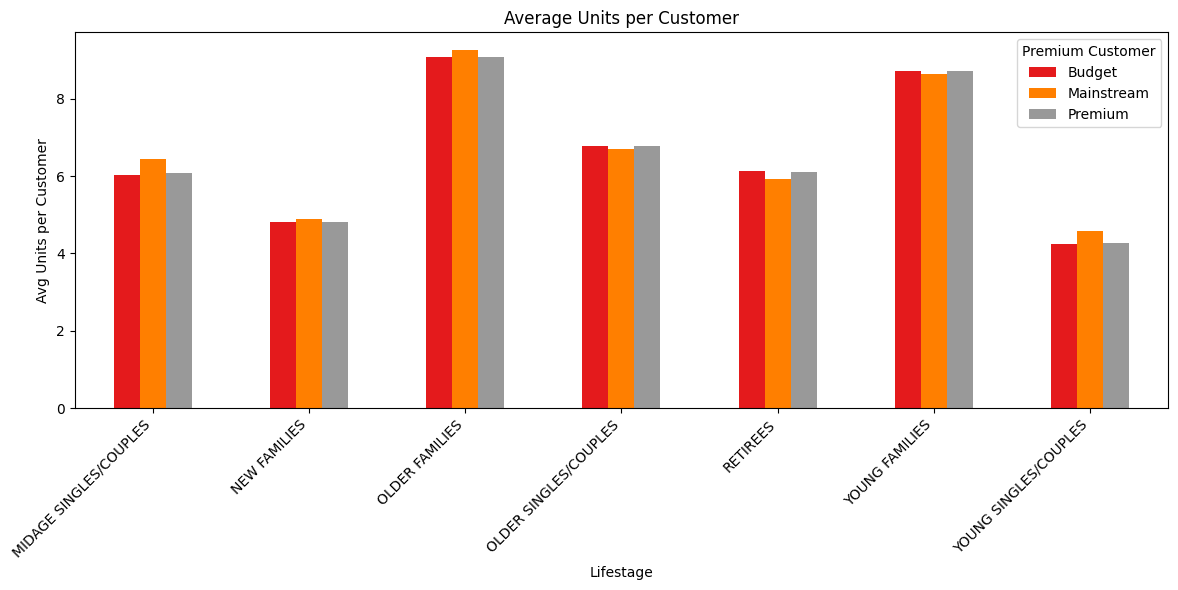

In [94]:
avg_units_pivot = avg_units.pivot(
    index="LIFESTAGE", columns="PREMIUM_CUSTOMER", values="AVG"
).fillna(0)

avg_units_pivot.plot(kind="bar", figsize=(12, 6), colormap="Set1")
plt.title("Average Units per Customer")
plt.xlabel("Lifestage")
plt.ylabel("Avg Units per Customer")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Premium Customer")
plt.tight_layout()
plt.savefig("avg_units_per_customer.png", dpi=150)
plt.show()

Older families and young families in general buy more chips per customer.

In [95]:
# Average Price per Unit
avg_price = (
    df.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .apply(lambda x: x["TOT_SALES"].sum() / x["PROD_QTY"].sum())
    .reset_index(name="AVG"))

/tmp/ipykernel_7592/3177355526.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["TOT_SALES"].sum() / x["PROD_QTY"].sum())


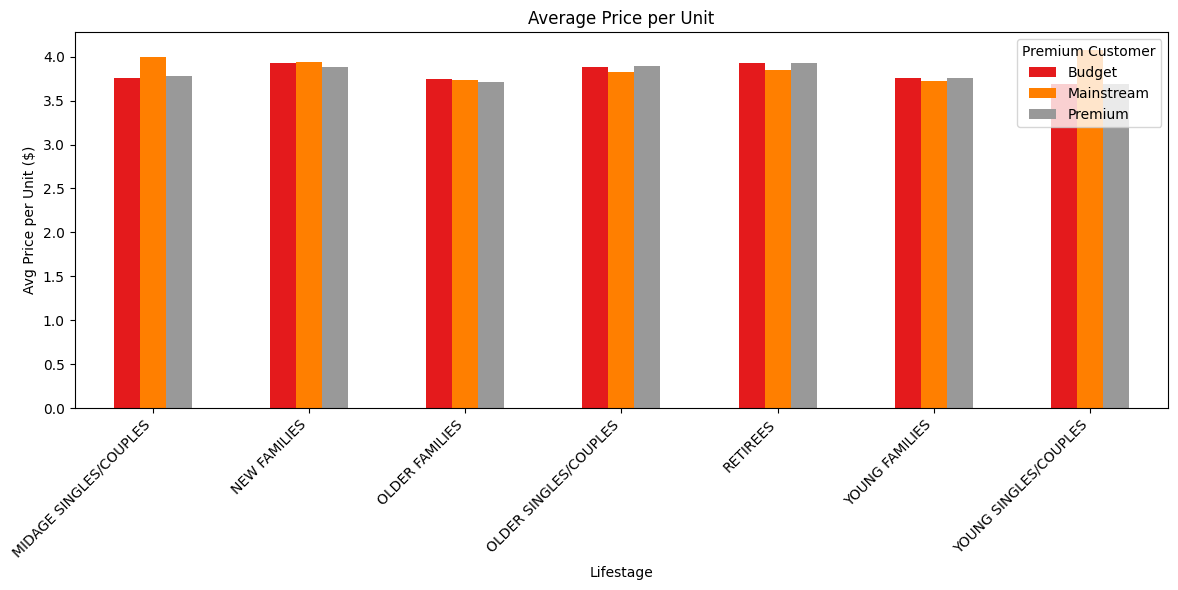

In [96]:
avg_price_pivot = avg_price.pivot(
    index="LIFESTAGE", columns="PREMIUM_CUSTOMER", values="AVG"
).fillna(0)

avg_price_pivot.plot(kind="bar", figsize=(12, 6), colormap="Set1")
plt.title("Average Price per Unit")
plt.xlabel("Lifestage")
plt.ylabel("Avg Price per Unit ($)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Premium Customer")
plt.tight_layout()
plt.savefig("avg_price_per_unit.png", dpi=150)
plt.show()


Mainstream midage and young singles and couples are more willing to pay more per packet of chips com
pared to their budget and premium counterparts. This may be due to premium shoppers being more likely to
buy healthy snacks and when they buychips,this is mainly for entertainment purposes rather than their own consumption. This is also supported by there being fewer premium midage and young singles and couples
buying chips compared to their mainstream counterparts.

### Statistical Test: Mainstream vs Budget/Premium

In [97]:
# (Young + Midage Singles/Couples)

df["PRICE"] = df["TOT_SALES"] / df["PROD_QTY"]

target_lifestages = ["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"]

mainstream_price = df[
    df["LIFESTAGE"].isin(target_lifestages) &
    (df["PREMIUM_CUSTOMER"] == "Mainstream")
]["PRICE"]

other_price = df[
    df["LIFESTAGE"].isin(target_lifestages) &
    (df["PREMIUM_CUSTOMER"] != "Mainstream")
]["PRICE"]

t_stat, p_value = stats.ttest_ind(mainstream_price, other_price, alternative="greater")

print("\n-Test: Mainstream vs Budget/Premium (Young + Midage Singles/Couples) ")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4e}")
print(f"Mean (Mainstream): {mainstream_price.mean():.4f}")
print(f"Mean (Other):      {other_price.mean():.4f}")



-Test: Mainstream vs Budget/Premium (Young + Midage Singles/Couples) 
t-statistic: 37.8320
p-value:     1.1178e-309
Mean (Mainstream): 4.0398
Mean (Other):      3.7065


The t-test results in a p-value < 2.2e-16, i.e. the unit price for mainstream, young and mid-age singles and
couples are significantly higher than that of budget or premium, young and midage singles and couples

###Deep dive into specific customer segments for insights

We have found quite a few interesting insights that we can dive deeper into.
We might want to target customer segments that contribute the most to sales to retain them or further
increase sales. Let’s look at Mainstream- young singles/couples. For instance, let’s find out if they tend to
buy a particular brand of chips.

In [98]:
# Deep Dive: Mainstream Young Singles/Couples
segment1 = df[
    (df["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") &
    (df["PREMIUM_CUSTOMER"] == "Mainstream")
].copy()

other = df[
    ~(
        (df["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") &
        (df["PREMIUM_CUSTOMER"] == "Mainstream")
    )
].copy()

quantity_segment1 = segment1["PROD_QTY"].sum()
quantity_other = other["PROD_QTY"].sum()

In [99]:
# Brand affinity
qty_seg1_brand = (
    segment1.groupby("BRAND")["PROD_QTY"].sum() / quantity_segment1
).reset_index(name="targetSegment")

qty_other_brand = (
    other.groupby("BRAND")["PROD_QTY"].sum() / quantity_other
).reset_index(name="other")

brand_proportions = qty_seg1_brand.merge(qty_other_brand, on="BRAND")
brand_proportions["affinityToBrand"] = (
    brand_proportions["targetSegment"] / brand_proportions["other"]
)

brand_proportions = brand_proportions.sort_values("affinityToBrand", ascending=False)

print("\n Brand Affinity (Mainstream Young Singles/Couples) ")
print(brand_proportions.to_string(index=False))



 Brand Affinity (Mainstream Young Singles/Couples) 
     BRAND  targetSegment    other  affinityToBrand
  TYRRELLS       0.031553 0.025693         1.228090
  TWISTIES       0.046184 0.037877         1.219314
   DORITOS       0.122761 0.101075         1.214547
    KETTLE       0.197985 0.165554         1.195891
  TOSTITOS       0.045411 0.037978         1.195708
  PRINGLES       0.119420 0.100635         1.186665
      COBS       0.044638 0.039049         1.143119
 INFUZIONS       0.064679 0.057065         1.133430
     THINS       0.060373 0.056987         1.059418
   GRNWVES       0.032712 0.031188         1.048868
  CHEEZELS       0.017971 0.018647         0.963749
    SMITHS       0.096370 0.124580         0.773561
    FRENCH       0.003948 0.005758         0.685566
   CHEETOS       0.008033 0.012067         0.665730
       RRD       0.043810 0.067494         0.649088
   NATURAL       0.019600 0.030854         0.635238
       CCS       0.011180 0.018896         0.591674
  SUNBITES 

We can see that :

• Mainstream young singles/couples are 25% more likely to purchase Tyrrells chips compared to the
rest of the population

• Mainstream youngsingles/couples are 56% less likely to purchase Burger Rings compared to the rest
of the population

In [100]:
# Pack size affinity
qty_seg1_pack = (
    segment1.groupby("PACK_SIZE")["PROD_QTY"].sum() / quantity_segment1
).reset_index(name="targetSegment")

qty_other_pack = (
    other.groupby("PACK_SIZE")["PROD_QTY"].sum() / quantity_other
).reset_index(name="other")

pack_proportions = qty_seg1_pack.merge(qty_other_pack, on="PACK_SIZE")
pack_proportions["affinityToPack"] = (
    pack_proportions["targetSegment"] / pack_proportions["other"]
)
pack_proportions = pack_proportions.sort_values("affinityToPack", ascending=False)

print("\n Pack Size Affinity (Mainstream Young Singles/Couples) ")
print(pack_proportions.to_string(index=False))



 Pack Size Affinity (Mainstream Young Singles/Couples) 
 PACK_SIZE  targetSegment    other  affinityToPack
     270.0       0.031829 0.025096        1.268281
     380.0       0.032160 0.025584        1.257024
     330.0       0.061284 0.050162        1.221711
     134.0       0.119420 0.100635        1.186665
     110.0       0.106280 0.089792        1.183632
     210.0       0.029124 0.025121        1.159313
     135.0       0.014769 0.013075        1.129505
     250.0       0.014355 0.012781        1.123161
     170.0       0.080773 0.080986        0.997365
     150.0       0.157598 0.163421        0.964368
     175.0       0.254990 0.270004        0.944394
     165.0       0.055652 0.062268        0.893753
     190.0       0.007481 0.012442        0.601268
     180.0       0.003589 0.006067        0.591536
     160.0       0.006404 0.012373        0.517613
      90.0       0.006349 0.012580        0.504696
     125.0       0.003009 0.006037        0.498440
     200.0       0.008972

It looks like Mainstream young singles/couples are 27% more likely to purchase a 270g pack of chips com
pared to the rest of the population but let’s dive into what brands sell this pack size.

In [101]:
# Which brand sells 270g packs?
print("\n Products with PACK_SIZE == 270 ")
print(df[df["PACK_SIZE"] == 270]["PROD_NAME"].unique())


 Products with PACK_SIZE == 270 
['Twisties Cheese     270g' 'Twisties Chicken270g']


Twisties are the only brand offering 270g packs and so this may instead be reflecting a higher likelihood of
purchasing Twisties.

Sales have mainly been due to Budget-older families,Main stream-young singles/couples, and Mainstream- retirees shoppers. We found that the high spend in chips for mainstream young singles/couples and re
tirees is due to there being more of them than other buyers. Mainstream, midage and young singles and
couples are also more likely to pay more per packet of chips. This is indicative of impulse buying behaviour.
We’ve also found that Mainstream young singles and couples are 25% more likely to purchase Tyrrells chips
compared to the rest of the population. The Category Manager may want to increase the category’s per
formance by off-locating some Tyrrells and smaller packs of chips in discretionary space near segments
where young singles and couples frequent more often to increase visibilty and impulse behaviour.
Quantium can help the Category Manager with recommendations of where these segments are and further
help them with measuring the impact of the changed placement. We’ll work on measuring the impact of
trials in the next task and putting all these together in the third task